# 22. Online feedback co-design of an adaptive sensor node

Every temporal example so far plans offline: the whole horizon is solved in advance and a policy is read out. This notebook closes the loop. A solar-powered environmental sensor node runs in the field, and at each control step it senses its current battery charge, reads the current data requirement and solar conditions, re-solves its co-design at those live conditions, applies the cheapest feasible configuration, and repeats.

The plan is never trusted to match reality: the next configuration is chosen from the *measured* state, so when conditions diverge from any forecast the loop simply re-solves against what actually happened. That is feedback, not open-loop replay. This is the co-design instance of **control co-design (CCD)** in its nested, receding-horizon form, here the myopic variant (re-solve a single static co-design at the current conditions each step).


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'onlinecd', os.path.join(PROJECT_ROOT, 'examples', '22_online_feedback_codesign.py'))
ex22 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ex22)

from codesign import run_online_codesign
print("Configs:", ", ".join(c.name for c in ex22.CONFIGS))
print(f"battery capacity {ex22.BATTERY_CAPACITY:.0f}, horizon {ex22.N_STEPS} steps")


Configs: low_power, nominal, high_rate
battery capacity 100, horizon 12 steps


## The scenario

The node runs in three sensing configurations (low_power, nominal, high_rate), each a co-design problem that sizes the radio and compute against the demanded data rate and is *gated by the measured charge* (a hungry configuration is infeasible when the battery is low, the feedback path). A storm raises the demanded data rate mid-run, and the solar recharge follows a day/storm/recovery profile.


In [2]:
print("step:   ", " ".join(f"{i:>3}" for i in range(ex22.N_STEPS)))
print("demand: ", " ".join(f"{d:>3}" for d in ex22.DEMAND_RATE))
print("solar:  ", " ".join(f"{s:>3}" for s in ex22.SOLAR))


step:      0   1   2   3   4   5   6   7   8   9  10  11
demand:    3   3   3   3   8   9   9   7   3   3   3   3
solar:    14  14  14  14  12  10   8   8  10  12  14  14


## Run the closed loop

At each step the loop senses the true battery charge (held by the plant), reads the live requirement (demand plus available charge) and environment (solar), re-solves the co-design, applies the cheapest feasible configuration, steps the true plant, and logs the outcome.


In [3]:
sensor, requirement, environment, plant = ex22.make_scenario()
result = run_online_codesign(
    ex22.CONFIGS, n_steps=ex22.N_STEPS, sensor=sensor, requirement=requirement,
    environment=environment, plant=plant, cost_fn=ex22.cost_fn,
    initial_state=ex22.BATTERY_CAPACITY)

print(f"{'t':>2}  {'soc_in':>6}  {'rate':>4}  {'solar':>5}  {'config':<10} {'energy':>6}  {'ops':>4}")
for s in result.steps:
    e = s.point['energy'] if s.feasible else float('nan')
    o = s.point['ops'] if s.feasible else float('nan')
    cfg = s.architecture if s.feasible else 'INFEASIBLE'
    print(f"{s.step:>2}  {s.measured_state:>6.1f}  {s.requirement['rate']:>4.0f}  "
          f"{s.environment['solar']:>5.0f}  {cfg:<10} {e:>6.1f}  {o:>4.1f}")
print(f"\nschedule: {' -> '.join(result.schedule)}")
print(f"total ops cost = {result.total_cost:.1f}, feasible = {result.feasible}")


 t  soc_in  rate  solar  config     energy   ops
 0   100.0     3     14  nominal      11.0   3.0
 1   100.0     3     14  nominal      11.0   3.0
 2   100.0     3     14  nominal      11.0   3.0
 3   100.0     3     14  nominal      11.0   3.0
 4   100.0     8     12  high_rate    34.0   1.0
 5    78.0     9     10  high_rate    37.0   1.0
 6    51.0     9      8  high_rate    37.0   1.0
 7    22.0     7      8  nominal      19.0   3.0
 8    11.0     3     10  nominal      11.0   3.0
 9    10.0     3     12  low_power     5.0   5.0
10    17.0     3     14  nominal      11.0   3.0
11    20.0     3     14  nominal      11.0   3.0

schedule: nominal -> nominal -> nominal -> nominal -> high_rate -> high_rate -> high_rate -> nominal -> nominal -> low_power -> nominal -> nominal
total ops cost = 32.0, feasible = True


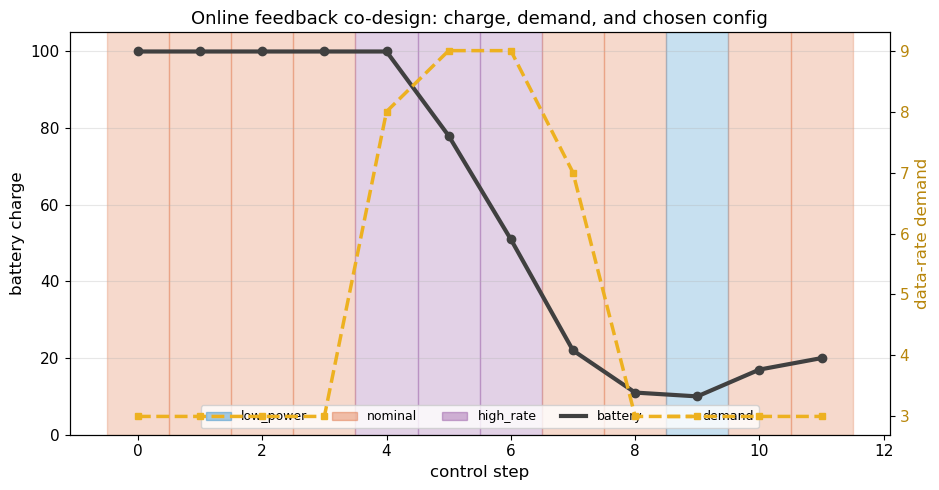

In [4]:
import matplotlib.pyplot as plt

# MATLAB gem colours, one per config.
CFG_COLOR = {"low_power": "#0072BD", "nominal": "#D95319", "high_rate": "#7E2F8E"}

steps = result.steps
xs = list(range(len(steps)))
soc = [s.measured_state for s in steps]
demand = [s.requirement["rate"] for s in steps]

fig, ax = plt.subplots(figsize=(9.5, 5.0))
# Battery trace (thick).
ax.plot(xs, soc, color="0.25", lw=3.0, marker="o", markersize=6,
        zorder=4, label="battery charge")
# Config bands.
for s in steps:
    c = CFG_COLOR.get(s.architecture, "0.6")
    ax.axvspan(s.step - 0.5, s.step + 0.5, color=c, alpha=0.22, zorder=1)
# Demand overlay on a twin axis.
ax2 = ax.twinx()
ax2.plot(xs, demand, color="#EDB120", lw=2.5, ls="--", marker="s",
         markersize=5, zorder=3, label="data-rate demand")
ax2.set_ylabel("data-rate demand", fontsize=12, color="#B8860B")
ax2.tick_params(axis="y", labelcolor="#B8860B", labelsize=11)

ax.set_xlabel("control step", fontsize=12)
ax.set_ylabel("battery charge", fontsize=12)
ax.set_title("Online feedback co-design: charge, demand, and chosen config",
             fontsize=13)
ax.set_ylim(0, ex22.BATTERY_CAPACITY * 1.05)
ax.grid(True, axis="y", alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)

from matplotlib.patches import Patch
handles = [Patch(color=c, alpha=0.35, label=n) for n, c in CFG_COLOR.items()]
handles.append(plt.Line2D([], [], color="0.25", lw=3.0, label="battery"))
handles.append(plt.Line2D([], [], color="#EDB120", lw=2.5, ls="--", label="demand"))
ax.legend(handles=handles, loc="lower center", fontsize=9, ncol=5, frameon=True)
fig.tight_layout()
plt.show()


## What the closed loop reveals

The node escalates to `high_rate` during the storm (the demand spike) when the rate justifies it, then the closed loop reads the depleting charge and the re-solve is gated: `high_rate` becomes infeasible, so the node falls back through `nominal` to `low_power`, and climbs back as solar recovers. No offline plan is followed. Each step is solved against the measured battery state, so the schedule adapts to how the deployment actually unfolds.

This is the myopic (option-a) form of online feedback co-design: re-solve a single static co-design at the live conditions each step. A receding-horizon lookahead that plans several steps ahead with the vector-state DP and commits only the first, and online learning of the co-design model from measurements, are the natural next increments; the model here is known, and measurements update the carried state and conditions rather than the model itself.
